# Task 2: Exploratory Data Analysis
## Ethiopia Financial Inclusion Forecasting

Analysis of patterns and factors influencing financial inclusion in Ethiopia, using the
enriched dataset from Task 1.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../data/processed/ethiopia_fi_unified_data_enriched.csv')
df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')

obs = df[df['record_type'] == 'observation'].copy()
events = df[df['record_type'] == 'event'].copy()
targets = df[df['record_type'] == 'target'].copy()
links = df[df['record_type'] == 'impact_link'].copy()

print(f"Observations: {len(obs)} | Events: {len(events)} | Targets: {len(targets)} | Impact links: {len(links)}")


Observations: 32 | Events: 10 | Targets: 3 | Impact links: 14


## 1. Dataset Overview

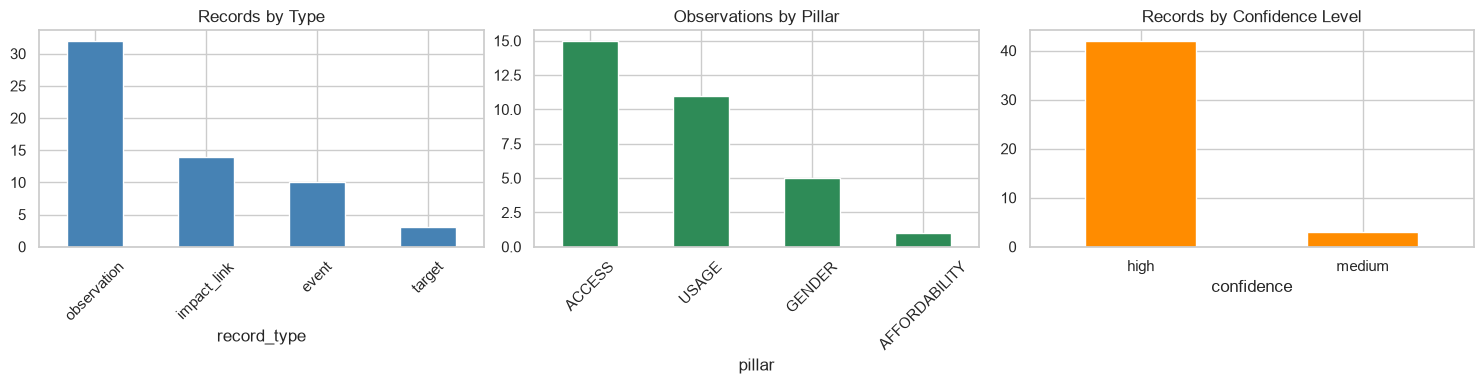

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['record_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Records by Type')
axes[0].tick_params(axis='x', rotation=45)

obs['pillar'].value_counts().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Observations by Pillar')
axes[1].tick_params(axis='x', rotation=45)

df['confidence'].value_counts().plot(kind='bar', ax=axes[2], color='darkorange')
axes[2].set_title('Records by Confidence Level')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../reports/figures/01_dataset_overview.png', bbox_inches='tight')
plt.show()


## 2. Temporal Coverage

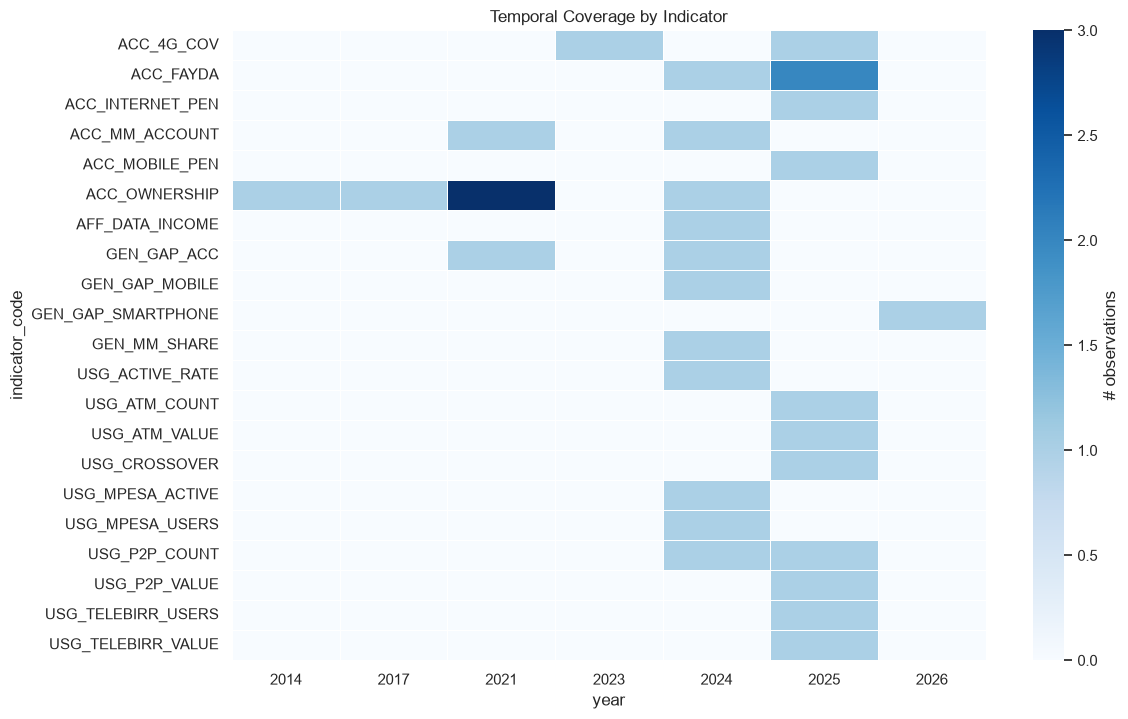

In [3]:
obs['year'] = obs['observation_date'].dt.year
coverage = obs.pivot_table(index='indicator_code', columns='year', values='value_numeric', aggfunc='count')
coverage = coverage.fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(12, max(4, len(coverage) * 0.35)))
sns.heatmap(coverage, cmap='Blues', cbar_kws={'label': '# observations'}, linewidths=0.5, ax=ax)
ax.set_title('Temporal Coverage by Indicator')
plt.tight_layout()
plt.savefig('../reports/figures/02_temporal_coverage.png', bbox_inches='tight')
plt.show()


## 3. Access Analysis: Account Ownership Trajectory

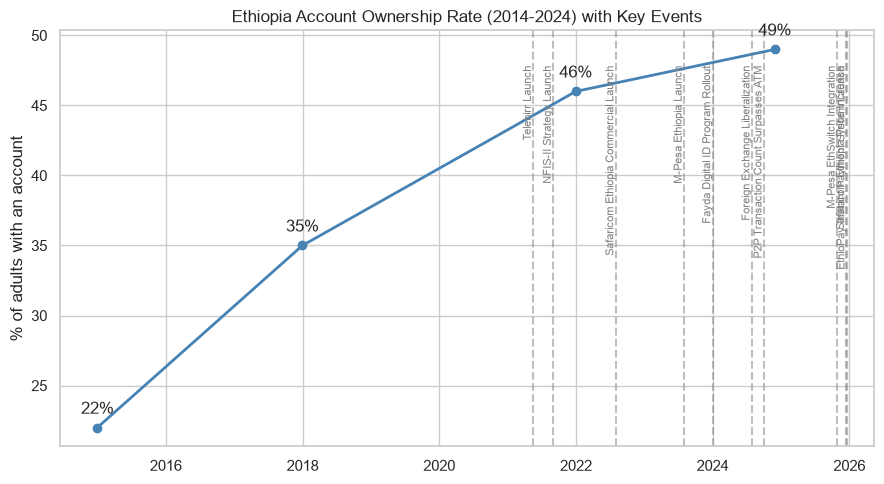

  observation_date  value_numeric
0       2014-12-31           22.0
1       2017-12-31           35.0
2       2021-12-31           46.0
5       2024-11-29           49.0


In [4]:
ownership = obs[(obs['indicator_code'] == 'ACC_OWNERSHIP') & (obs['gender'] == 'all')].sort_values('observation_date')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ownership['observation_date'], ownership['value_numeric'], marker='o', linewidth=2, color='steelblue')
for _, row in ownership.iterrows():
    ax.annotate(f"{row['value_numeric']:.0f}%", (row['observation_date'], row['value_numeric']),
                textcoords='offset points', xytext=(0, 10), ha='center')

# overlay events
for _, ev in events.iterrows():
    ax.axvline(ev['observation_date'], color='gray', linestyle='--', alpha=0.5)
    ax.text(ev['observation_date'], ax.get_ylim()[1]*0.95, ev['indicator'], rotation=90,
            va='top', ha='right', fontsize=8, color='gray')

ax.set_title("Ethiopia Account Ownership Rate (2014-2024) with Key Events")
ax.set_ylabel('% of adults with an account')
plt.tight_layout()
plt.savefig('../reports/figures/03_ownership_trajectory.png', bbox_inches='tight')
plt.show()

print(ownership[['observation_date', 'value_numeric']])


### Growth rates between survey years

In [5]:
ownership_sorted = ownership.sort_values('observation_date').reset_index(drop=True)
ownership_sorted['pp_change'] = ownership_sorted['value_numeric'].diff()
ownership_sorted['years_elapsed'] = ownership_sorted['observation_date'].dt.year.diff()
ownership_sorted['pp_per_year'] = ownership_sorted['pp_change'] / ownership_sorted['years_elapsed']
ownership_sorted[['observation_date', 'value_numeric', 'pp_change', 'pp_per_year']]


,observation_date,value_numeric,pp_change,pp_per_year
0,2014-12-31,22.0,NaN,NaN
1,2017-12-31,35.0,13.0,4.333333
2,2021-12-31,46.0,11.0,2.750000
3,2024-11-29,49.0,3.0,1.000000


### The 2021-2024 slowdown

Account ownership grew only +3pp between 2021 and 2024, despite Telebirr (2021) and M-Pesa
(2023) both launching in this window and mobile money accounts growing substantially. Candidate
explanations to investigate:
- Mobile money accounts may be substituting for, not adding to, bank account growth (people who
  already had bank accounts adopting mobile money, rather than the previously unbanked)
- Per the Enrichment Guide (Sheet D), mobile-money-only users are rare in Ethiopia (~0.5%) -
  meaning most new mobile money adoption is *not* translating into new "account ownership" as
  Findex measures it for people who lacked any account before
- The 2021 Findex survey may have already captured an early Telebirr adoption bump (Telebirr
  launched May 2021, survey likely fielded mid-to-late 2021), leaving less runway for 2021-2024
  measured growth
- FX Liberalization (2024) and broader macroeconomic conditions may have offset gains


### Gender Gap in Account Ownership

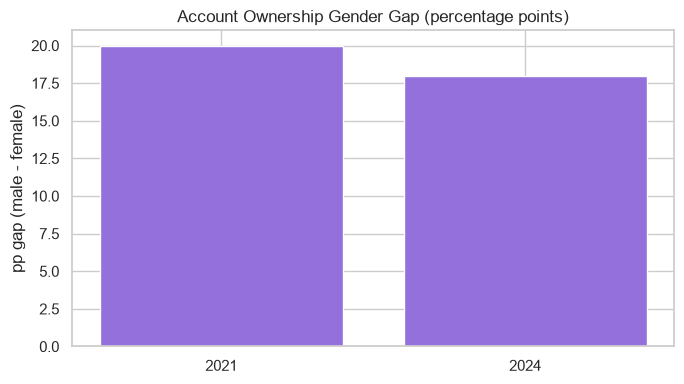

   observation_date  value_numeric
26       2021-12-31           20.0
27       2024-11-29           18.0


In [6]:
gender_gap = obs[obs['indicator_code'] == 'GEN_GAP_ACC'].sort_values('observation_date')

if len(gender_gap) > 0:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(gender_gap['observation_date'].dt.year.astype(str), gender_gap['value_numeric'], color='mediumpurple')
    ax.set_title('Account Ownership Gender Gap (percentage points)')
    ax.set_ylabel('pp gap (male - female)')
    plt.tight_layout()
    plt.savefig('../reports/figures/04_gender_gap.png', bbox_inches='tight')
    plt.show()
    print(gender_gap[['observation_date', 'value_numeric']])
else:
    print("No GEN_GAP_ACC observations found.")


## 4. Usage (Digital Payments) Analysis

Usage indicators available: ['USG_P2P_COUNT', 'USG_P2P_VALUE', 'USG_ATM_COUNT', 'USG_ATM_VALUE', 'USG_CROSSOVER', 'USG_TELEBIRR_USERS', 'USG_TELEBIRR_VALUE', 'USG_MPESA_USERS', 'USG_MPESA_ACTIVE', 'USG_ACTIVE_RATE']


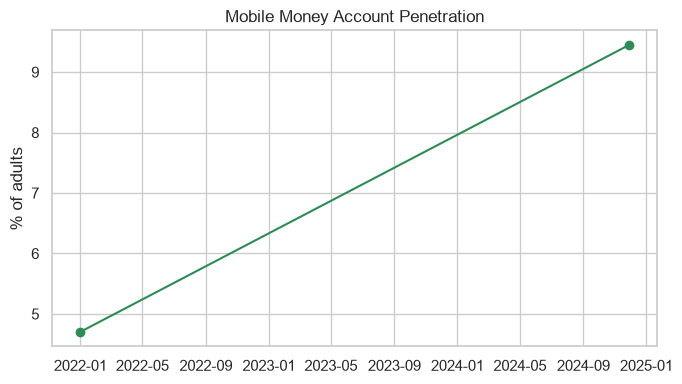

In [7]:
usage_indicators = obs[obs['pillar'] == 'USAGE']['indicator_code'].unique()
print("Usage indicators available:", list(usage_indicators))

mm_account = obs[obs['indicator_code'] == 'ACC_MM_ACCOUNT'].sort_values('observation_date')
if len(mm_account) > 1:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(mm_account['observation_date'], mm_account['value_numeric'], marker='o', color='seagreen')
    ax.set_title('Mobile Money Account Penetration')
    ax.set_ylabel('% of adults')
    plt.tight_layout()
    plt.savefig('../reports/figures/05_mm_account_trend.png', bbox_inches='tight')
    plt.show()


## 5. Event Timeline

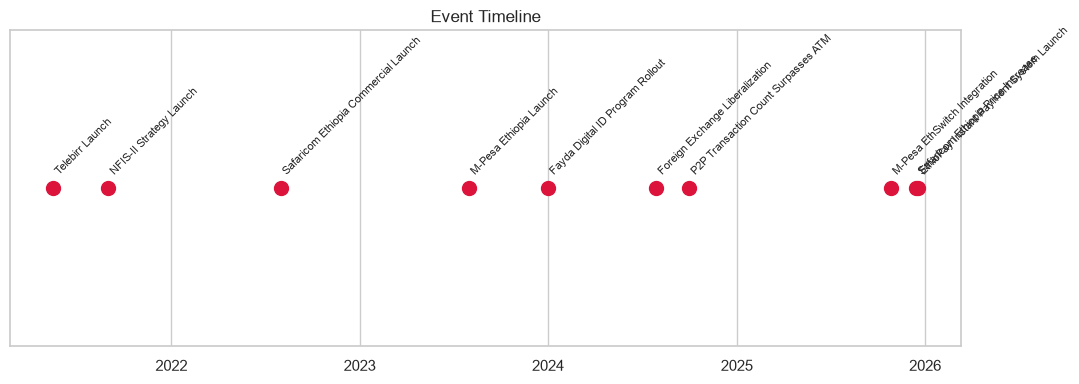

,observation_date,category,indicator
33,2021-05-17,product_launch,Telebirr Launch
41,2021-09-01,policy,NFIS-II Strategy Launch
34,2022-08-01,market_entry,Safaricom Ethiopia Commercial Launch
35,2023-08-01,product_launch,M-Pesa Ethiopia Launch
36,2024-01-01,infrastructure,Fayda Digital ID Program Rollout
37,2024-07-29,policy,Foreign Exchange Liberalization
38,2024-10-01,milestone,P2P Transaction Count Surpasses ATM
39,2025-10-27,partnership,M-Pesa EthSwitch Integration
42,2025-12-15,pricing,Safaricom Ethiopia Price Increase
40,2025-12-18,infrastructure,EthioPay Instant Payment System Launch


In [8]:
events_sorted = events.sort_values('observation_date')

fig, ax = plt.subplots(figsize=(11, 4))
ax.scatter(events_sorted['observation_date'], [1]*len(events_sorted), s=100, color='crimson', zorder=3)
for _, ev in events_sorted.iterrows():
    ax.annotate(ev['indicator'], (ev['observation_date'], 1), rotation=45,
                textcoords='offset points', xytext=(0, 10), ha='left', fontsize=8)
ax.get_yaxis().set_visible(False)
ax.set_title('Event Timeline')
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.savefig('../reports/figures/06_event_timeline.png', bbox_inches='tight')
plt.show()

events_sorted[['observation_date', 'category', 'indicator']]


## 6. Correlation Analysis

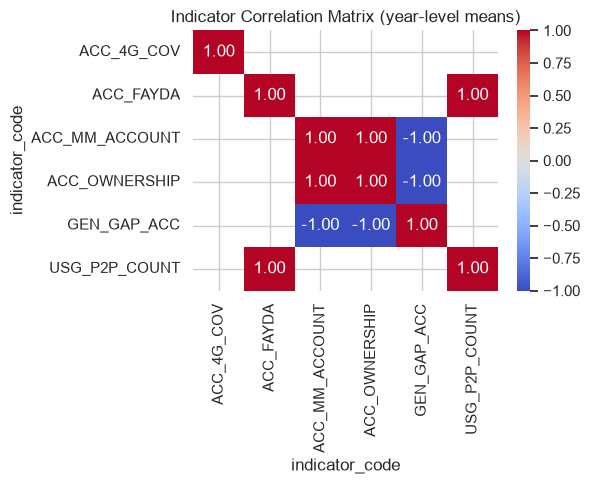

In [9]:
pivot = obs[obs['gender']=='all'].pivot_table(index='year', columns='indicator_code', values='value_numeric', aggfunc='mean')
# keep only indicators with at least 2 non-null years so correlation is meaningful
pivot = pivot.loc[:, pivot.notna().sum() >= 2]

if pivot.shape[1] >= 2:
    corr = pivot.corr()
    fig, ax = plt.subplots(figsize=(max(6, corr.shape[0]*0.6), max(5, corr.shape[0]*0.5)))
    sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', ax=ax)
    ax.set_title('Indicator Correlation Matrix (year-level means)')
    plt.tight_layout()
    plt.savefig('../reports/figures/07_correlation_matrix.png', bbox_inches='tight')
    plt.show()
else:
    print("Not enough overlapping indicator-year data for a meaningful correlation matrix yet.")


**Caveat on correlation matrix:** several pairs show exactly 1.00 or -1.00 (e.g.
ACC_MM_ACCOUNT/ACC_OWNERSHIP/GEN_GAP_ACC). This is a mathematical artifact, not a genuine
strong relationship: most indicator pairs here only overlap on 2 measured years, and any
2-point series has a Pearson correlation of exactly +-1.00 by definition. These values
should not be read as evidence of a real relationship - they reflect data sparsity, which
is itself one of the central limitations of this dataset (see Data Quality Assessment below).
Pairs with 3+ overlapping years would be more trustworthy, but very few indicator pairs in
this dataset currently have that much overlap.

## 7. Impact Links Review

In [10]:
links_view = links.merge(
    events[['record_id', 'indicator']].rename(columns={'record_id': 'parent_id', 'indicator': 'event_name'}),
    on='parent_id', how='left'
)
links_view[['parent_id', 'event_name', 'related_indicator', 'impact_direction', 'impact_magnitude', 'lag_months', 'evidence_basis', 'comparable_country']]


,parent_id,event_name,related_indicator,impact_direction,impact_magnitude,lag_months,evidence_basis,comparable_country
0,EVT_0001,Telebirr Launch,ACC_OWNERSHIP,increase,medium,12.0,literature,Kenya
1,EVT_0001,Telebirr Launch,ACC_MM_ACCOUNT,increase,high,3.0,empirical,NaN
2,EVT_0001,Telebirr Launch,USG_P2P_COUNT,increase,high,6.0,empirical,NaN
3,EVT_0002,Safaricom Ethiopia Commercial Launch,ACC_MOBILE_PEN,increase,medium,12.0,theoretical,Kenya
4,EVT_0003,M-Pesa Ethiopia Launch,ACC_MM_ACCOUNT,increase,high,6.0,empirical,NaN
5,EVT_0003,M-Pesa Ethiopia Launch,USG_MPESA_USERS,increase,high,3.0,empirical,NaN
6,EVT_0004,Fayda Digital ID Program Rollout,ACC_FAYDA,increase,high,0.0,empirical,NaN
7,EVT_0004,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,increase,low,18.0,theoretical,India
8,EVT_0005,Foreign Exchange Liberalization,ACC_OWNERSHIP,mixed,low,6.0,theoretical,NaN
9,EVT_0006,P2P Transaction Count Surpasses ATM,USG_ATM_COUNT,decrease,medium,0.0,empirical,NaN


## 8. Key Insights

1. **Account ownership growth has decelerated sharply**: from +13pp (2014-2017) and +11pp
   (2017-2021) to just +3pp (2021-2024), despite the launch of Telebirr and M-Pesa in this
   window - suggesting mobile money expansion is not translating one-for-one into new account
   ownership as Findex measures it.
2. **Mobile money accounts grew much faster than overall account ownership** (4.7% to 9.45% of
   adults, 2021-2024) than the headline Access metric (46% to 49%) - consistent with the
   Enrichment Guide's note that mobile-money-only users are rare in Ethiopia (~0.5%), implying
   most new mobile money adoption is happening among people who already had some form of account.
3. **The gender gap in account ownership is narrowing** but remains substantial, and the gender
   gap in smartphone ownership (34%, GSMA 2026) is even wider than the account ownership gap -
   suggesting device access, not just account access, is a binding constraint on Usage in
   particular for women.
4. **Events cluster heavily in 2023-2025**: most of the catalogued events (M-Pesa entry, Fayda
   rollout, FX liberalization, EthioPay, M-Pesa/EthSwitch interoperability) occurred after the
   last Findex survey point (2024) - meaning their effects on Access/Usage cannot yet be directly
   observed in survey data and must be modeled using operator-reported proxies and comparable-
   country evidence (addressed in Task 3).
5. **Data is unevenly distributed across time**: 2025 alone accounts for roughly a third of all
   observations (mostly operator/regulator reports), while 2014-2021 combined has far fewer -
   meaning recent granular operator data is rich, but long-run survey-based trend data remains
   sparse (only 4 Findex data points for Access spanning 10 years), which is the central
   challenge for Task 4's forecasting approach.

## Data Quality Assessment

- **Strengths**: confidence is high for the overwhelming majority of records; sources are a mix
  of survey (Findex), operator, and regulator data, providing some triangulation.
- **Limitations**: Access (account ownership) has only 4 true survey time points over 13 years -
  any trend model fit to this alone has very few degrees of freedom. Usage indicators are mostly
  single-year snapshots (2024 or 2025), with no historical trend to anchor a regression on. Event
  effects are necessarily estimated from comparable-country evidence rather than fitted Ethiopian
  pre/post data for the majority of 2023-2025 events, since they postdate the last Findex survey.
